***Data Loading***: The diabetic_data.csv file was loaded into a pandas DataFrame, providing the raw dataset for analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file into a DataFrame
df = pd.read_csv('diabetic_data.csv')

# Display the first few rows of the DataFrame to confirm
print(df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

***Data Cleaning (Column Dropping)***: Irrelevant or sensitive columns such as encounter_id, patient_nbr, weight, payer_code, medical_specialty, and num_lab_procedures were dropped to simplify the dataset and protect privacy.

In [2]:
columns_to_drop = ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty', 'num_lab_procedures']

# Filter columns_to_drop to only include columns that exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

# Drop the specified columns that exist
df = df.drop(columns=existing_columns_to_drop)

# Display the first few rows of the DataFrame to confirm the removal


***Data Cleaning (Missing Values)***: Missing values in max_glu_serum and A1Cresult columns were identified and imputed using their respective modes, ensuring no missing data in these critical features

In [3]:
missing_values = df.isnull().sum()

# Display columns with missing values and their counts
missing_values_cols = missing_values[missing_values > 0]

if not missing_values_cols.empty:
    print('Columns with missing values:')
    print(missing_values_cols)
else:
    print('No missing values found in the DataFrame.')

Columns with missing values:
max_glu_serum    96420
A1Cresult        84748
dtype: int64


In [4]:
# Impute 'max_glu_serum' with its mode
max_glu_serum_mode = df['max_glu_serum'].mode()[0]
df['max_glu_serum'] = df['max_glu_serum'].fillna(max_glu_serum_mode)

# Impute 'A1Cresult' with its mode
A1Cresult_mode = df['A1Cresult'].mode()[0]
df['A1Cresult'] = df['A1Cresult'].fillna(A1Cresult_mode)

print("Missing values after imputation:")
print(df[['max_glu_serum', 'A1Cresult']].isnull().sum())

Missing values after imputation:
max_glu_serum    0
A1Cresult        0
dtype: int64


***Feature Engineering (One-Hot Encoding)***: Categorical features were converted into numerical format using one-hot encoding, making them suitable for machine learning algorithms. This significantly expanded the feature space.

In [5]:
# Identify categorical columns (object type)
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame
print("DataFrame after one-hot encoding:")
print(df_encoded.head())

# Display the shape of the DataFrame before and after encoding
print(f"\nOriginal DataFrame shape: {df.shape}")
print(f"Encoded DataFrame shape: {df_encoded.shape}")

DataFrame after one-hot encoding:
   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  num_procedures  num_medications  number_outpatient  \
0                 1               0                1                  0   
1                 3               0               18                  0   
2                 2               5               13                  2   
3                 2               1               16                  0   
4                 1               0                8                  0   

   number_emergency  number_inpatient  number_diagnoses  ...  \
0                 0     

***Feature Scaling***: Selected numerical features (e.g., time_in_hospital, num_medications) were scaled using StandardScaler to normalize their ranges, which is important for many machine learning models.

In [6]:
from sklearn.preprocessing import StandardScaler
import numpy as np # Ensure numpy is imported for np.number

columns_to_scale = [
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'time_in_hospital', 'num_procedures', 'num_medications', 'number_outpatient',
    'number_emergency', 'number_inpatient', 'number_diagnoses'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical columns
df_scaled_features = df_encoded.copy() # Create a copy to store scaled features
df_scaled_features[columns_to_scale] = scaler.fit_transform(df_scaled_features[columns_to_scale])

print("DataFrame with scaled features (first 5 rows of scaled numerical columns):")
print(df_scaled_features[columns_to_scale].head())

print("\nFull DataFrame head after scaling:")
print(df_scaled_features.head())

DataFrame with scaled features (first 5 rows of scaled numerical columns):
   admission_type_id  discharge_disposition_id  admission_source_id  \
0           2.750800                  4.031022            -1.169873   
1          -0.708461                 -0.514312             0.306482   
2          -0.708461                 -0.514312             0.306482   
3          -0.708461                 -0.514312             0.306482   
4          -0.708461                 -0.514312             0.306482   

   time_in_hospital  num_procedures  num_medications  number_outpatient  \
0         -1.137649       -0.785398        -1.848268          -0.291461   
1         -0.467653       -0.785398         0.243390          -0.291461   
2         -0.802651        2.145781        -0.371804           1.286748   
3         -0.802651       -0.199162        -0.002688          -0.291461   
4         -1.137649       -0.785398        -0.986997          -0.291461   

   number_emergency  number_inpatient  number_d

***Data Splitting***: The dataset was split into training (80%) and testing (20%) sets, with readmitted_>30 as the target variable, ensuring a proper evaluation of the model's generalization ability.

In [7]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Assuming 'readmitted_>30' is the primary target for readmission prediction
# and we will drop other readmitted columns to avoid multicollinearity

X = df_scaled_features.drop(columns=['readmitted_>30', 'readmitted_NO'])
y = df_scaled_features['readmitted_>30']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (81412, 2333)
Shape of X_test: (20354, 2333)
Shape of y_train: (81412,)
Shape of y_test: (20354,)


***Model Training***: A Random Forest Classifier was initialized with class_weight='balanced' to handle potential class imbalance and then trained on the preprocessed training data.

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# You can tune hyperparameters like n_estimators, max_depth, etc., later for optimization
model = RandomForestClassifier(class_weight='balanced')

# Train the model on the training data
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


***Model Evaluation***: The trained model's performance was evaluated using various metrics including Accuracy (56.49%), Precision (42.86%), Recall (73.81%), F1-Score (54.23%), and ROC AUC Score (65.02%). Confusion Matrix and ROC curves were also plotted for visual assessment.

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make predictions on the test set
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class
y_pred = (y_pred_proba > 0.3).astype(int)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Model Evaluation Metrics:")
print(f"Accuracy(%): {accuracy*100:.4f}")
print(f"Precision(%): {precision*100:.4f}")
print(f"Recall(%): {recall*100:.4f}")
print(f"F1-Score(%): {f1*100:.4f}")
print(f"ROC AUC Score(%): {roc_auc*100:.4f}")

Model Evaluation Metrics:
Accuracy(%): 56.0136
Precision(%): 42.5016
Recall(%): 73.5124
F1-Score(%): 53.8624
ROC AUC Score(%): 64.7635


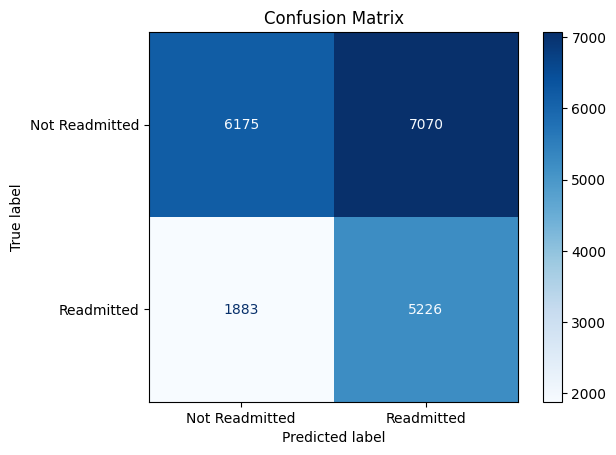

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=[False, True])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

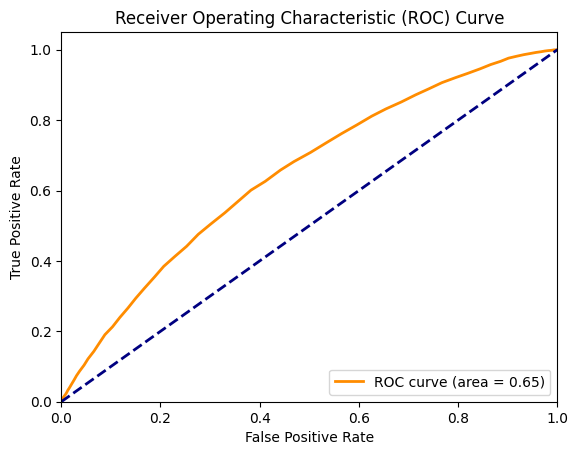

In [11]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

***Exploratory Data Analysis (EDA)***: Visualizations were generated to explore the distribution of readmission status, its relationship with number_inpatient, time_in_hospital, num_medications, and the impact of insulin treatment, providing insights into the dataset.

<Axes: xlabel='readmitted'>

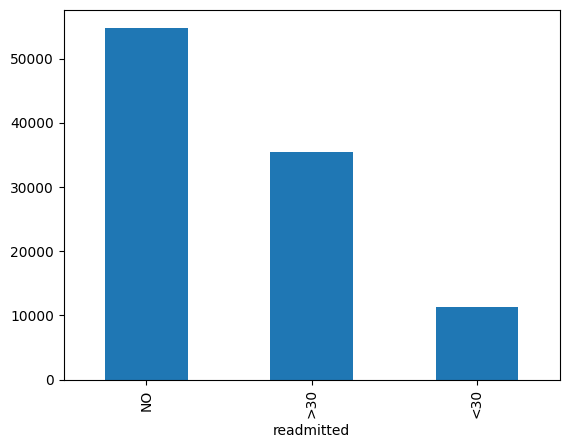

In [12]:
df['readmitted'].value_counts().plot(kind='bar')

<Axes: xlabel='readmitted', ylabel='number_inpatient'>

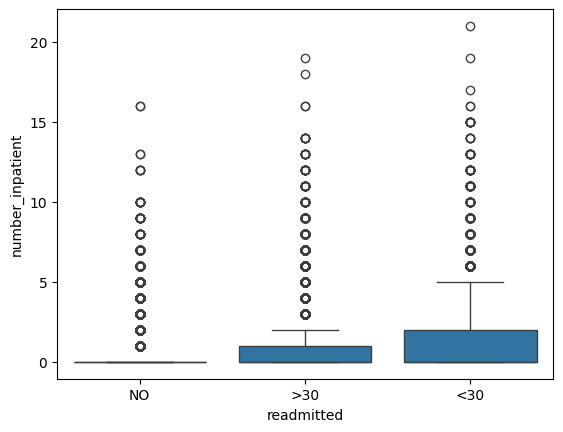

In [13]:
sns.boxplot(x='readmitted', y='number_inpatient', data=df)

<Axes: xlabel='readmitted', ylabel='time_in_hospital'>

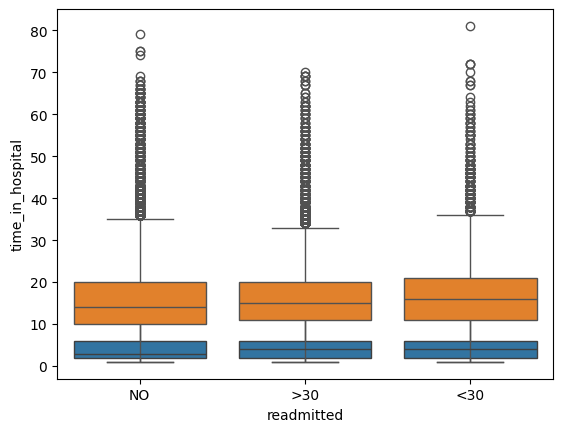

In [15]:
sns.boxplot(x='readmitted', y='time_in_hospital', data=df)
sns.boxplot(x='readmitted', y='num_medications', data=df)

<Axes: xlabel='readmitted', ylabel='num_medications'>

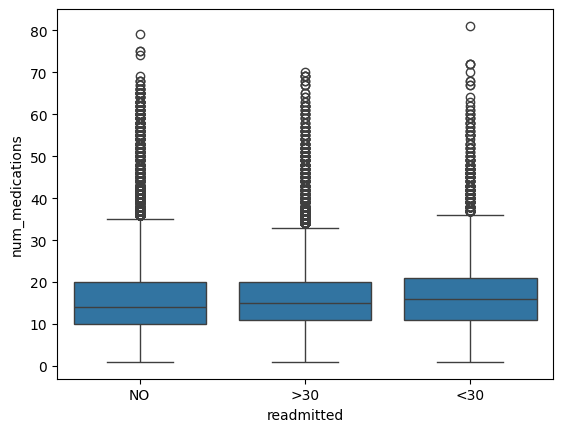

In [16]:
sns.boxplot(x='readmitted', y='num_medications', data=df)

<Axes: xlabel='insulin', ylabel='count'>

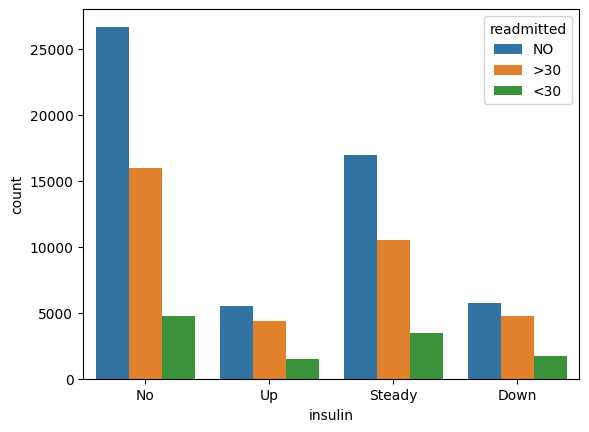

In [17]:
sns.countplot(x='insulin', hue='readmitted', data=df)


***Feature Importance***: The importance of each feature in predicting readmission was calculated and displayed, highlighting num_medications and time_in_hospital as the most influential factors.

In [18]:
importance = model.feature_importances_
features = X.columns

pd.Series(importance, index=features).sort_values(ascending=False).head(10)

,0
num_medications,0.055736
time_in_hospital,0.042982
discharge_disposition_id,0.032706
number_diagnoses,0.031848
number_inpatient,0.028805
num_procedures,0.027985
admission_type_id,0.022109
admission_source_id,0.019445
number_outpatient,0.015953
gender_Male,0.015693


***Data Export***: The final cleaned and preprocessed dataset, df_scaled_features, was exported to a new CSV file named diabetic_data_cleaned.csv, making it ready for future use or deployment.

In [ ]:
df_scaled_features.to_csv('diabetic_data_cleaned.csv', index=False)
print('Cleaned data exported to diabetic_data_cleaned.csv')